# Relative symmetry-repair notebook

This notebook demonstrates a practical **relative symmetry-repair spectrum** for elementary cellular automata.

The workflow is:

1. simulate a rule on a periodic ring;
2. scan relative-periodic background models `(shift, period)`;
3. project the spacetime field onto the nearest background satisfying  
   `B[t + p, (x + s) mod W] = B[t, x]`;
4. measure the defect field by defect rate and repair-code proxies;
5. inspect connected defect world-tubes in the best fit.

The notebook also includes a simple reflection-symmetry example showing that **equal Hamming defect counts can still have different repair codelengths**.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from relative_symmetry_repair.eca import random_initial_state, simulate_eca
from relative_symmetry_repair.plotting import plot_decomposition, plot_spacetime, plot_spectrum
from relative_symmetry_repair.repair import (
    extract_components,
    fit_reflection_symmetric_state,
    scan_relative_periodicity,
    summarise_components,
)

OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 20)

## 1. Simulate a shared initial condition across several benchmark rules

We use the same random initial state for Rules 30, 54, and 110.

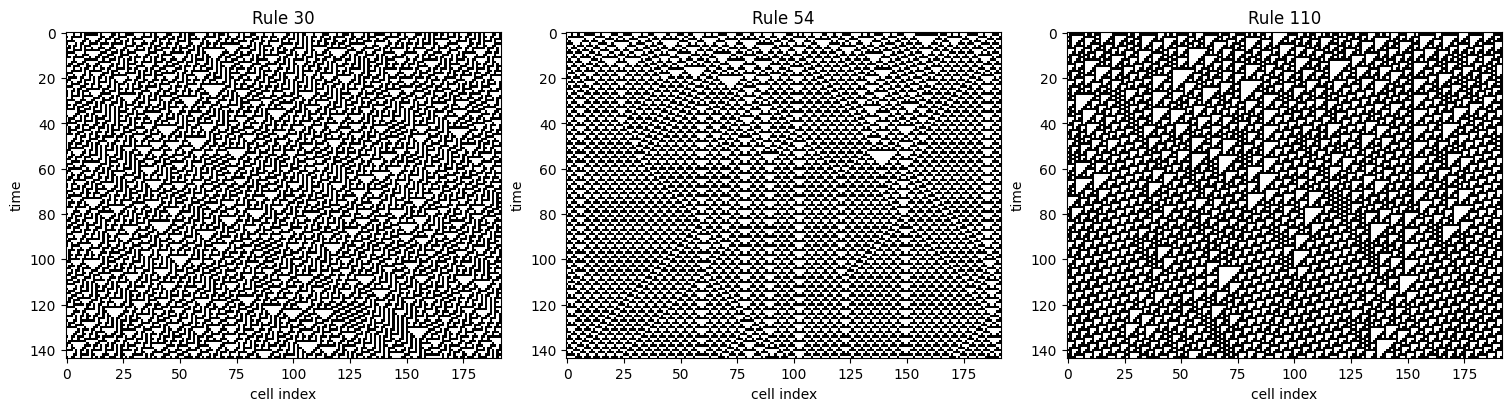

In [2]:
WIDTH = 192
STEPS = 144
SEED = 11
DENSITY = 0.5

initial = random_initial_state(width=WIDTH, density=DENSITY, seed=SEED)
rules = [30, 54, 110]
spacetimes = {rule: simulate_eca(rule=rule, initial=initial, steps=STEPS) for rule in rules}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, rule in zip(axes, rules):
    ax.imshow(spacetimes[rule], aspect="auto", interpolation="nearest", cmap="binary")
    ax.set_title(f"Rule {rule}")
    ax.set_xlabel("cell index")
    ax.set_ylabel("time")
plt.show()

## 2. Scan the relative-periodic spectrum

For each rule, we scan shifts in `[-6, 6]` and periods in `[1, 10]`.
The scan reports defect rate, repair proxies, and local-rule inconsistency of the fitted background.

In [3]:
SHIFT_RANGE = range(-6, 7)
PERIOD_RANGE = range(1, 11)

spectra = {}
fits = {}

for rule, spacetime in spacetimes.items():
    frame, fit_map = scan_relative_periodicity(
        spacetime,
        shifts=SHIFT_RANGE,
        periods=PERIOD_RANGE,
        rule=rule,
    )
    spectra[rule] = frame
    fits[rule] = fit_map

summary_rows = []
for rule, frame in spectra.items():
    best = frame.sort_values(["defect_rate", "rule_error", "run_length_bits"]).iloc[0]
    summary_rows.append(
        {
            "rule": rule,
            "best_shift": int(best["shift"]),
            "best_period": int(best["period"]),
            "defect_rate": float(best["defect_rate"]),
            "run_length_bits": int(best["run_length_bits"]),
            "lz4_bits": int(best["lz4_bits"]),
            "rule_error": float(best["rule_error"]),
        }
    )

summary = pd.DataFrame(summary_rows).sort_values("rule").reset_index(drop=True)
summary

,rule,best_shift,best_period,defect_rate,run_length_bits,lz4_bits,rule_error
0,30,-5,10,0.391204,30656,27832,0.363491
1,54,0,8,0.200629,19840,20472,0.111233
2,110,0,7,0.308304,25924,27728,0.211174


The summary table makes the comparison explicit: Rule 30 is harder to fit with a sparse low-error background, while Rules 54 and 110 exhibit lower-defect minima and lower background rule error.

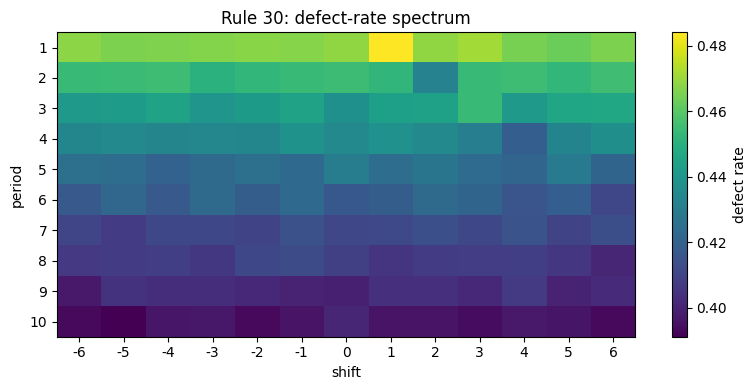

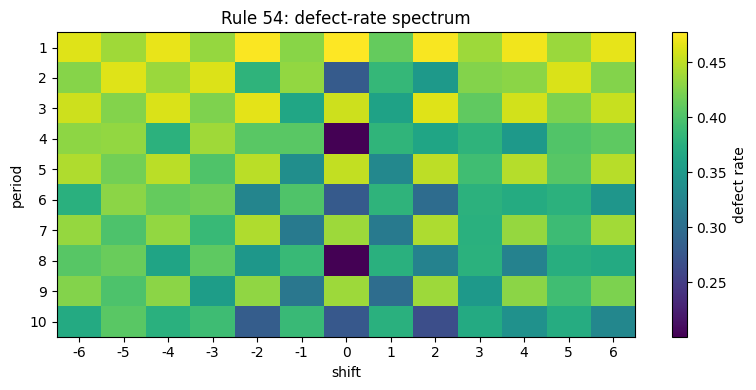

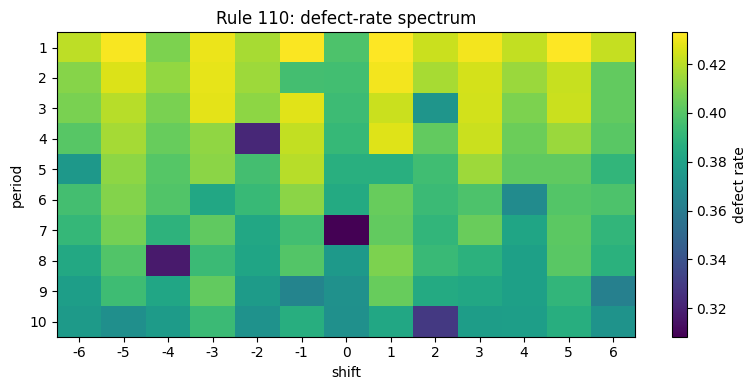

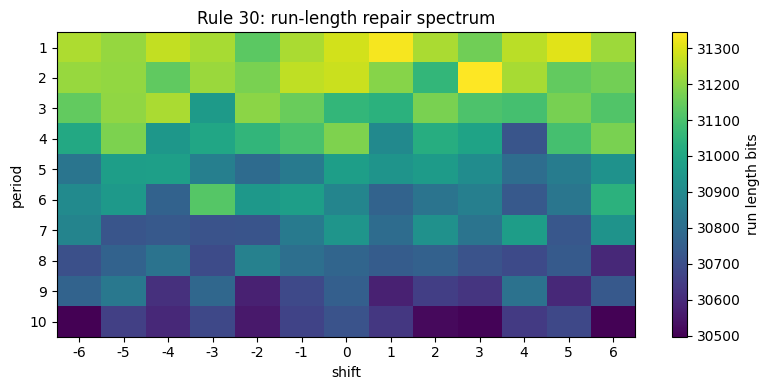

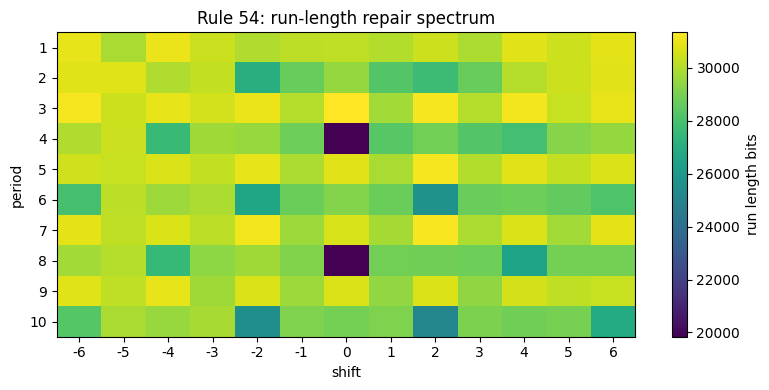

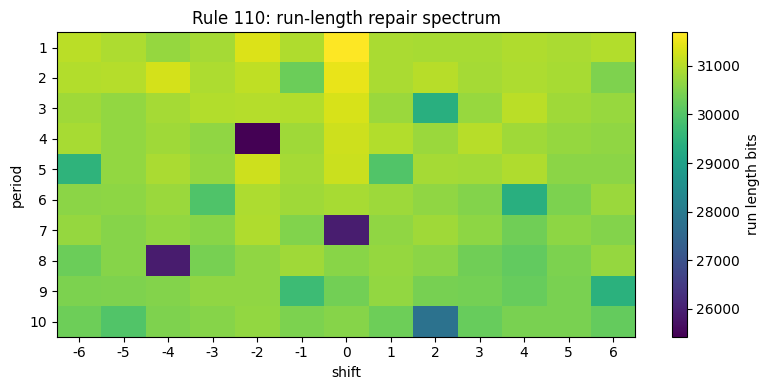

In [4]:
for rule in rules:
    fig, _ = plot_spectrum(
        spectra[rule],
        value="defect_rate",
        title=f"Rule {rule}: defect-rate spectrum",
    )
    plt.show()

for rule in rules:
    fig, _ = plot_spectrum(
        spectra[rule],
        value="run_length_bits",
        title=f"Rule {rule}: run-length repair spectrum",
    )
    plt.show()

## 3. Inspect the best-fit decomposition and connected defect components

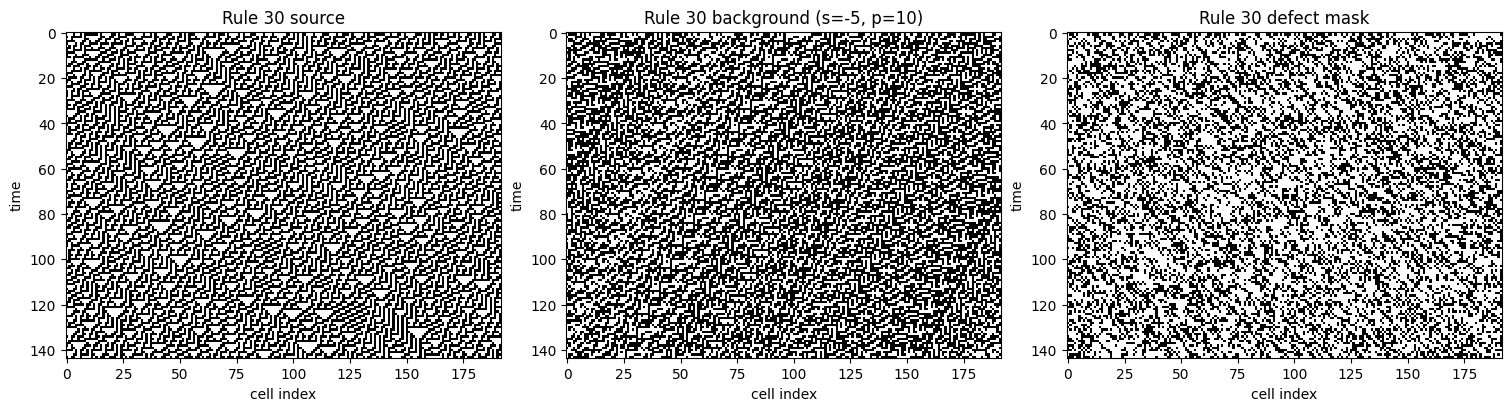

Top defect components for Rule 30


,label,size,t_min,t_max,time_span,x_min,x_max,x_span
0,4,8111,0,143,144,0,191,192
1,24,345,2,48,47,162,191,30
2,222,146,95,124,30,161,183,23
3,167,106,76,99,24,139,160,22
4,209,227,92,114,23,92,134,43
5,176,109,81,101,21,119,141,23
6,215,71,94,114,21,149,160,12
7,301,96,125,143,19,0,19,20
8,271,57,114,132,19,182,191,10
9,264,45,112,128,17,7,17,11


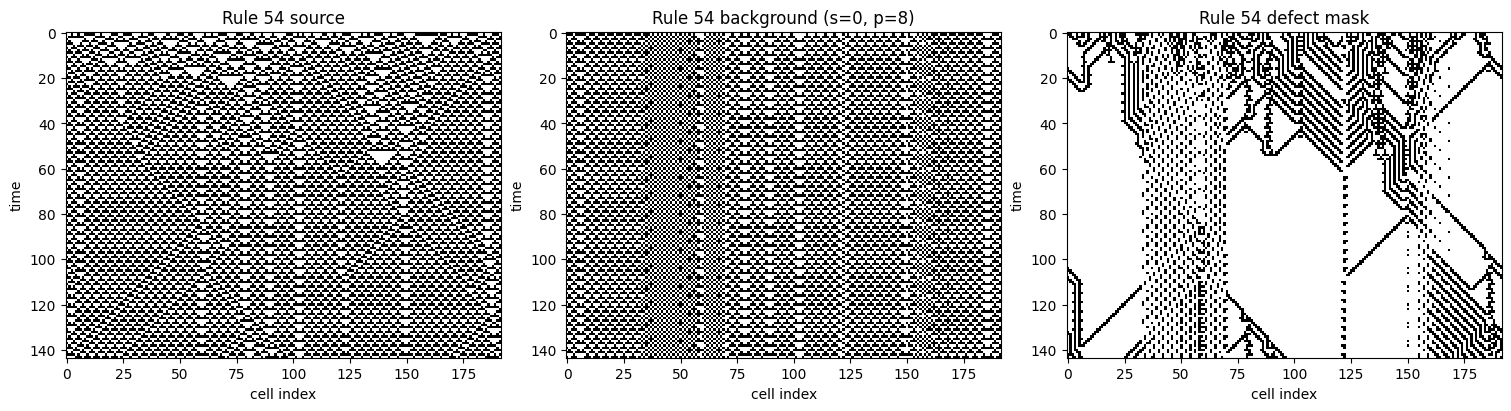

Top defect components for Rule 54


,label,size,t_min,t_max,time_span,x_min,x_max,x_span
0,12,1012,0,86,87,121,162,42
1,314,429,72,143,72,159,191,33
2,7,1068,0,61,62,66,121,56
3,2,195,0,55,56,0,33,34
4,3,174,0,46,47,21,35,15
5,15,115,0,39,40,161,191,31
6,489,47,108,143,36,0,6,7
7,467,100,104,138,35,0,32,33
8,521,139,114,143,30,69,96,28
9,525,55,114,143,30,159,184,26


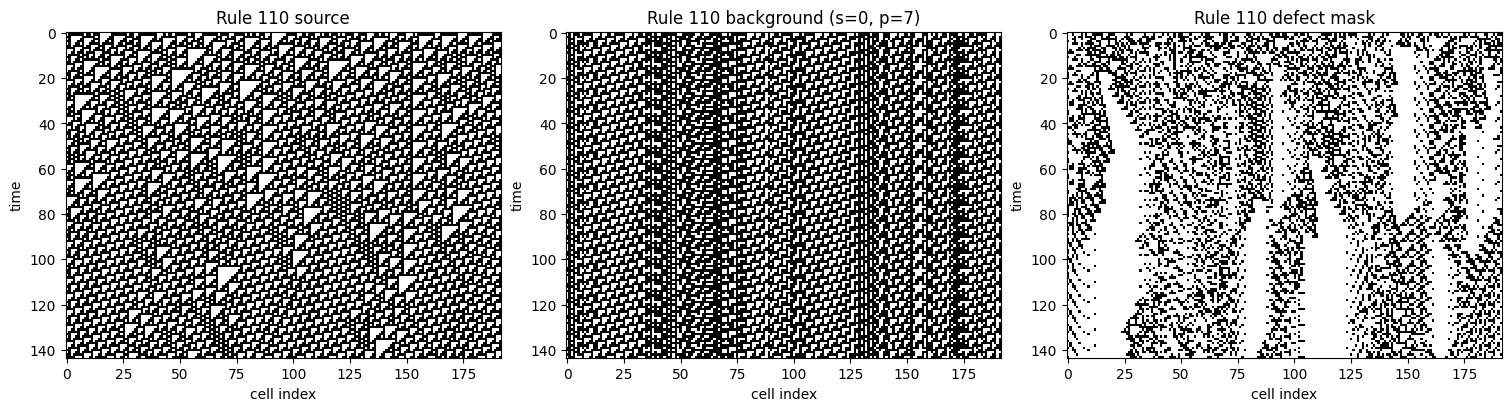

Top defect components for Rule 110


,label,size,t_min,t_max,time_span,x_min,x_max,x_span
0,4,3079,0,143,144,32,135,104
1,2,990,0,107,108,0,42,43
2,233,778,75,143,69,127,162,36
3,258,441,82,143,62,168,191,24
4,10,598,0,53,54,157,191,35
5,354,271,107,143,37,47,75,29
6,371,216,111,143,33,24,43,20
7,7,106,0,27,28,126,142,17
8,67,101,28,55,28,130,142,13
9,208,119,69,92,24,160,176,17


In [5]:
best_fits = {}
component_tables = {}

for rule in rules:
    best_row = spectra[rule].sort_values(["defect_rate", "rule_error", "run_length_bits"]).iloc[0]
    key = (int(best_row["shift"]), int(best_row["period"]))
    best_fit = fits[rule][key]
    best_fits[rule] = best_fit

    fig, _ = plot_decomposition(best_fit, source=spacetimes[rule], title_prefix=f"Rule {rule} ")
    plt.show()

    labels, _ = extract_components(best_fit.defect_mask, min_size=6)
    component_table = summarise_components(labels).head(10)
    component_tables[rule] = component_table
    print(f"Top defect components for Rule {rule}")
    display(component_table)

## 4. Reflection example: same defect count, different repair codelength

This is the simplest computational backing for the statement that **repair information can refine Hamming distance**.

We start from an exactly mirror-symmetric background and inject the same number of defects in two different ways:
- one clustered block;
- one random scatter.

Both states have the same number of mismatched mirror pairs, but their repair masks compress differently.

In [6]:
N = 512
M = 64
rng = np.random.default_rng(1234)

base = np.zeros(N, dtype=np.uint8)

clustered = base.copy()
clustered[40:40 + M] = 1

randomised = base.copy()
random_positions = rng.choice(np.arange(N // 2), size=M, replace=False)
randomised[random_positions] = 1

clustered_fit = fit_reflection_symmetric_state(clustered)
random_fit = fit_reflection_symmetric_state(randomised)

comparison = pd.DataFrame(
    [
        {"case": "clustered", **clustered_fit.to_record()},
        {"case": "random", **random_fit.to_record()},
    ]
)
comparison

,case,defect_sites,total_sites,defect_rate,combinatorial_bits,run_length_bits,lz4_bits
0,clustered,64,512,0.125,274.073657,42,304
1,random,64,512,0.125,274.073657,251,496


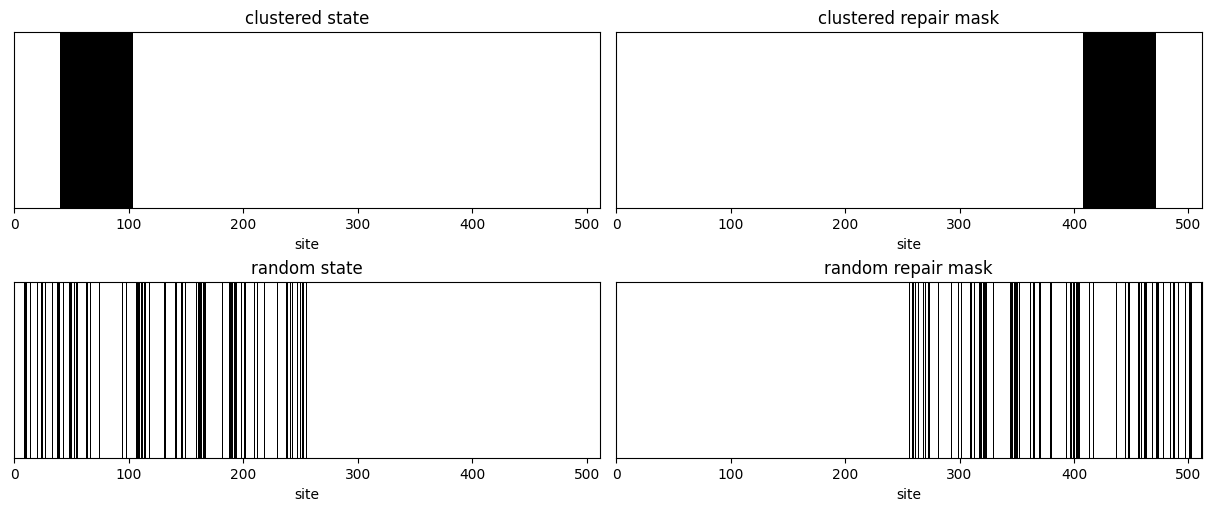

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5), constrained_layout=True)

axes[0, 0].imshow(clustered[np.newaxis, :], aspect="auto", interpolation="nearest", cmap="binary")
axes[0, 0].set_title("clustered state")
axes[0, 1].imshow(clustered_fit.defect_mask[np.newaxis, :], aspect="auto", interpolation="nearest", cmap="binary")
axes[0, 1].set_title("clustered repair mask")

axes[1, 0].imshow(randomised[np.newaxis, :], aspect="auto", interpolation="nearest", cmap="binary")
axes[1, 0].set_title("random state")
axes[1, 1].imshow(random_fit.defect_mask[np.newaxis, :], aspect="auto", interpolation="nearest", cmap="binary")
axes[1, 1].set_title("random repair mask")

for ax in axes.ravel():
    ax.set_xlabel("site")
    ax.set_yticks([])
plt.show()

## 5. Save notebook outputs

The next cell writes a compact CSV summary of the best fits and the reflection example so you can reuse the data in the manuscript.

In [8]:
summary.to_csv(OUTPUT_DIR / "best_relative_periodic_fits.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "reflection_repair_comparison.csv", index=False)

summary, comparison

(   rule  best_shift  best_period  defect_rate  run_length_bits  lz4_bits  \
 0    30          -5           10     0.391204            30656     27832   
 1    54           0            8     0.200629            19840     20472   
 2   110           0            7     0.308304            25924     27728   
 
    rule_error  
 0    0.363491  
 1    0.111233  
 2    0.211174  ,
         case  defect_sites  total_sites  defect_rate  combinatorial_bits  \
 0  clustered            64          512        0.125          274.073657   
 1     random            64          512        0.125          274.073657   
 
    run_length_bits  lz4_bits  
 0               42       304  
 1              251       496  )